In [1]:
import pandas as pd

In [5]:
data = pd.read_csv("./../data/creditcard.csv")
data.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
data.shape

(284807, 31)

In [7]:
data.describe(), data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

(                Time            V1            V2            V3            V4  \
 count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
 mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
 std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
 min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
 25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
 50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
 75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
 max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   
 
                  V5            V6            V7            V8            V9  \
 count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
 mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
 std    1.380247e+00  1.33227

In [8]:
duplicates = data.duplicated().sum()
duplicates

np.int64(1081)

In [9]:
dup_mask = data.duplicated(keep=False)
print("Fraud rate در کل داده:", data['Class'].mean())
print("Fraud rate در ردیف‌های تکراری:", data[dup_mask]['Class'].mean())
print("تعداد فراد در بین duplicateها :", data[dup_mask]['Class'].sum())

Fraud rate در کل داده: 0.001727485630620034
Fraud rate در ردیف‌های تکراری: 0.017259978425026967
تعداد فراد در بین duplicateها : 32


In [10]:
data["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [11]:
missing_rows = data[data.isnull().any(axis=1)]
missing_rows

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# X = data.drop("Class", axis=1)
# y = data["Class"]

print("قبل:", data.shape, "| فراد:", data['Class'].sum())
data_clean = data.drop_duplicates(keep='first').reset_index(drop=True)
print("بعد:", data_clean.shape, "| فراد:", data_clean['Class'].sum())


قبل: (284807, 31) | فراد: 492
بعد: (283726, 31) | فراد: 473


In [15]:
data_clean["Class"].value_counts(normalize=True)

Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64

In [16]:
X = data_clean.drop("Class", axis=1)
y = data_clean["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

merged = X_train.merge(X_test, how='inner')
print("همپوشانی باقی‌مانده بین train/test:", len(merged))

همپوشانی باقی‌مانده بین train/test: 0


1. پس از حذف Duplicateها، تعداد نمونه‌ها از **284,807** به **283,726** و تعداد Fraudها از **492** به **473** رسید.
2. حذف Duplicateها باعث حذف 19 Fraud شد؛ این تصمیم یک Trade-off دارد، اما از حضور نمونه‌های کاملاً یکسان در Train و Test جلوگیری می‌کند.
3. Split به‌صورت **80/20 Stratified** انجام شده است.
4. بررسی انجام‌شده نشان می‌دهد همپوشانی Exact Record بین Train و Test برابر **0** است.
5. Scaling در Pipeline و بعد از Split انجام می‌شود؛ بنابراین Test/Validation Data در Fit شدن Scaler استفاده نمی‌شود.


In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix


def build_pipeline(model):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", model)
    ])


def evaluate_model(selected_model, X_train_raw, y_train_raw, X_test_raw, y_test_raw, cv=5):

    # ساخت Pipeline
    pipeline = build_pipeline(selected_model)

    # ساخت Cross Validation
    cv_strategy = StratifiedKFold(
        n_splits=cv,
        shuffle=True,
        random_state=42
    )

    # ارزیابی با Cross Validation
    scores = cross_validate(
        pipeline,
        X_train_raw,
        y_train_raw,
        cv=cv_strategy,
        scoring=["precision", "recall", "f1"]
    )

    cv_precision = scores["test_precision"].mean()
    cv_recall = scores["test_recall"].mean()
    cv_f1 = scores["test_f1"].mean()

    # آموزش Pipeline روی کل داده‌های Train
    pipeline.fit(X_train_raw, y_train_raw)

    # پیش‌بینی روی Test
    y_pred = pipeline.predict(X_test_raw)

    # محاسبه معیارهای Test
    test_precision = precision_score(y_test_raw, y_pred)
    test_recall = recall_score(y_test_raw, y_pred)
    test_f1 = f1_score(y_test_raw, y_pred)
    test_cm = confusion_matrix(y_test_raw, y_pred)

    return {
        "cv_precision": cv_precision,
        "cv_recall": cv_recall,
        "cv_f1": cv_f1,
        "test_precision": test_precision,
        "test_recall": test_recall,
        "test_f1": test_f1,
        "test_confusion_matrix": test_cm
    }

**LogisticRegression**

In [32]:
from sklearn.linear_model import LogisticRegression
import pprint as Pprint

results_lr = evaluate_model(
    selected_model=LogisticRegression(),
    X_train_raw=X_train,
    y_train_raw=y_train,
    X_test_raw=X_test,
    y_test_raw=y_test
)

Pprint.pprint(results_lr)

{'cv_f1': array([0.69918699, 0.68253968, 0.67213115, 0.74074074, 0.75362319]),
 'cv_precision': array([0.89583333, 0.84313725, 0.89130435, 0.84745763, 0.83870968]),
 'cv_recall': array([0.57333333, 0.57333333, 0.53947368, 0.65789474, 0.68421053]),
 'test_confusion_matrix': array([[56641,    10],
       [   40,    55]]),
 'test_f1': 0.6875,
 'test_precision': 0.8461538461538461,
 'test_recall': 0.5789473684210527}


**KNeighborsClassifier**

In [30]:
from sklearn.neighbors import KNeighborsClassifier

results_knn = evaluate_model(
    selected_model=KNeighborsClassifier(n_neighbors=5),   # فعلا پیش‌فرض، n_neighbors=5
    X_train_raw=X_train,
    y_train_raw=y_train,
    X_test_raw=X_test,
    y_test_raw=y_test
)

Pprint.pprint(results_knn)

{'cv_f1': array([0.85925926, 0.86131387, 0.6870229 , 0.87837838, 0.87323944]),
 'cv_precision': array([0.96666667, 0.9516129 , 0.81818182, 0.90277778, 0.93939394]),
 'cv_recall': array([0.77333333, 0.78666667, 0.59210526, 0.85526316, 0.81578947]),
 'test_confusion_matrix': array([[56648,     3],
       [   30,    65]]),
 'test_f1': 0.7975460122699386,
 'test_precision': 0.9558823529411765,
 'test_recall': 0.6842105263157895}


**DecisionTreeClassifier**

In [34]:
from sklearn.tree import DecisionTreeClassifier

results_tree = evaluate_model(
    selected_model=DecisionTreeClassifier(random_state=42),
    X_train_raw=X_train,
    y_train_raw=y_train,
    X_test_raw=X_test,
    y_test_raw=y_test
)

Pprint.pprint(results_tree)

{'cv_f1': array([0.73381295, 0.7114094 , 0.73825503, 0.76923077, 0.79487179]),
 'cv_precision': array([0.796875  , 0.71621622, 0.75342466, 0.75      , 0.775     ]),
 'cv_recall': array([0.68      , 0.70666667, 0.72368421, 0.78947368, 0.81578947]),
 'test_confusion_matrix': array([[56625,    26],
       [   28,    67]]),
 'test_f1': 0.7127659574468085,
 'test_precision': 0.7204301075268817,
 'test_recall': 0.7052631578947368}


In [53]:
tree_pipeline = build_pipeline(DecisionTreeClassifier(class_weight='balanced', random_state=42))
tree_pipeline.fit(X_train, y_train)
y_train_pred = tree_pipeline.predict(X_train)
train_f1 = f1_score(y_train, y_train_pred)

print(train_f1)
print(results_tree["cv_f1"])

1.0
0.7327658393741319


Report results:

| Model | Mean Precision | Mean Recall | Mean F1 |
|---|---:|---:|---:|
| Logistic Regression |0.061|0.918|0.113|
| KNN |0.916|0.765|0.832|
| Decision Tree |0.760|0.709|0.733|

# **Experiment 1**



- KNN با Scaling

In [35]:
knn_scaled = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=5))])
scores_scaled = cross_validate(
    knn_scaled, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=["precision", "recall", "f1"]
)
precision_scaled = scores_scaled["test_precision"].mean()
recall_scaled = scores_scaled["test_recall"].mean()
f1_scaled = scores_scaled["test_f1"].mean()

In [36]:
print("precision scaled ", precision_scaled)
print("recall scaled ", recall_scaled)
print("f1 scaled ", f1_scaled)

precision scaled  0.9157266210492019
recall scaled  0.7646315789473684
f1 scaled  0.8318427687267708


- KNN بدون Scaling

In [37]:
knn_raw = KNeighborsClassifier(n_neighbors=5)
scores_raw = cross_validate(
    knn_raw, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=["precision", "recall", "f1"]
)
precision_raw = scores_raw["test_precision"].mean()
recall_raw = scores_raw["test_recall"].mean()
f1_raw = scores_raw["test_f1"].mean()

In [38]:
print("precision rew ", precision_raw)
print("recall rew ", recall_raw)
print("f1 raw ", f1_raw)

precision rew  0.8
recall rew  0.013228070175438597
f1 raw  0.025975778607357558


| Model | Scaling | Precision | Recall |   F1 |
|---|---|----------:|-------:|-----:|
| KNN | Without Scaling |       0.8 |   0.01 | 0.02 |
| KNN | With Scaling |      0.91 |   0.76 | 0.83 |

# **Experiment 2**

In [39]:
max_depths = [2, 5, 10, None]
results = []
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for depth in max_depths:
    pipeline = Pipeline([("clf", DecisionTreeClassifier(max_depth=depth, class_weight="balanced", random_state=42))])
    pipeline.fit(X_train, y_train)
    train_f1 = f1_score(y_train, pipeline.predict(X_train))
    scores = cross_validate(pipeline, X_train, y_train, cv=cv_strategy,  scoring=["precision", "recall", "f1"])
    results.append({
        "max_depth": "None" if depth is None else depth,
        "train_f1": train_f1,
        "cv_precision": scores["test_precision"].mean(),
        "cv_recall": scores["test_recall"].mean(),
        "cv_f1": scores["test_f1"].mean(),
    })
for r in results:
    print(r)

{'max_depth': 2, 'train_f1': 0.12092515024585686, 'cv_precision': np.float64(0.0510429676724096), 'cv_recall': np.float64(0.8756842105263157), 'cv_f1': np.float64(0.09629293952384524)}
{'max_depth': 5, 'train_f1': 0.08197088465845465, 'cv_precision': np.float64(0.05899353047066484), 'cv_recall': np.float64(0.851859649122807), 'cv_f1': np.float64(0.11027535719827594)}
{'max_depth': 10, 'train_f1': 0.42736009044657997, 'cv_precision': np.float64(0.1882391218890694), 'cv_recall': np.float64(0.8016491228070175), 'cv_f1': np.float64(0.30102020957845765)}
{'max_depth': 'None', 'train_f1': 1.0, 'cv_precision': np.float64(0.759547048739443), 'cv_recall': np.float64(0.7090877192982457), 'cv_f1': np.float64(0.7327658393741319)}


/home/mahilda/Desktop/Study/MS/.venv/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


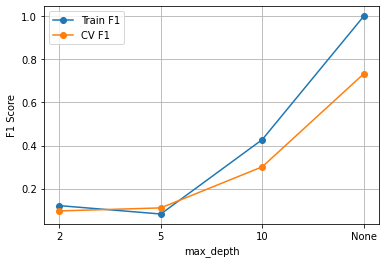

In [40]:
import matplotlib.pyplot as plt

depth_labels = [str(r["max_depth"]) for r in results]
plt.plot(depth_labels, [r["train_f1"] for r in results], marker="o", label="Train F1")
plt.plot(depth_labels, [r["cv_f1"] for r in results], marker="o", label="CV F1")
plt.xlabel("max_depth"); plt.ylabel("F1 Score"); plt.legend(); plt.grid(True)
plt.show()

In [41]:
required = {2, 5, 10, "None"}
project_table = [r for r in results if r["max_depth"] in required]
pd.DataFrame(project_table)

,max_depth,train_f1,cv_precision,cv_recall,cv_f1
0,2,0.120925,0.051043,0.875684,0.096293
1,5,0.081971,0.058994,0.851860,0.110275
2,10,0.427360,0.188239,0.801649,0.301020
3,None,1.000000,0.759547,0.709088,0.732766


| max_depth | Train F1 | CV Precision | CV Recall | CV F1 |
|---|---:|---:|---:|---:|
| 2 | 0.121 | 0.051 | **0.876** | 0.096 |
| 5 | 0.082 | 0.059 | 0.852 | 0.110 |
| 10 | 0.427 | 0.188 | 0.802 | 0.301 |
| None | **1.000** | **0.760** | 0.709 | **0.733** |

# **Experiment 3**

In [44]:
lr_pipeline = build_pipeline(LogisticRegression())
lr_pipeline.fit(X_train, y_train)
y_proba = lr_pipeline.predict_proba(X_test)[:, 1]
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
threshold_results = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    threshold_results.append({
        'threshold': t,
        'precision': precision_score(y_test, y_pred_t),
        'recall': recall_score(y_test, y_pred_t),
        'f1': f1_score(y_test, y_pred_t),
    })
pd.DataFrame(threshold_results)

,threshold,precision,recall,f1
0,0.1,0.833333,0.736842,0.782123
1,0.3,0.835616,0.642105,0.726190
2,0.5,0.846154,0.578947,0.687500
3,0.7,0.844828,0.515789,0.640523
4,0.9,0.826923,0.452632,0.585034


انتخاب ترشهولد برای مدل نهاییم که درخت تصمیم هستش

In [45]:
tree_final = build_pipeline(DecisionTreeClassifier(max_depth=None, random_state=42))
tree_final.fit(X_train, y_train)

y_proba_tree = tree_final.predict_proba(X_test)[:, 1]

threshold_results_tree = []
for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    y_pred_t = (y_proba_tree >= t).astype(int)
    threshold_results_tree.append({
        'threshold': t,
        'precision': precision_score(y_test, y_pred_t),
        'recall': recall_score(y_test, y_pred_t),
        'f1': f1_score(y_test, y_pred_t),
    })

pd.DataFrame(threshold_results_tree)

,threshold,precision,recall,f1
0,0.1,0.72043,0.705263,0.712766
1,0.2,0.72043,0.705263,0.712766
2,0.3,0.72043,0.705263,0.712766
3,0.4,0.72043,0.705263,0.712766
4,0.5,0.72043,0.705263,0.712766
5,0.6,0.72043,0.705263,0.712766
6,0.7,0.72043,0.705263,0.712766
7,0.8,0.72043,0.705263,0.712766
8,0.9,0.72043,0.705263,0.712766


In [72]:
import numpy as np
print(np.unique(y_proba_tree))
print("تعداد مقادیر یکتای احتمال:", len(np.unique(y_proba_tree)))

[0. 1.]
تعداد مقادیر یکتای احتمال: 2


### Logistic Regression

با افزایش Threshold از 0.1 تا 0.9:

- Precision از **0.009** به **0.262** افزایش یافت.
- Recall از **0.937** به **0.832** کاهش یافت.
- بیشترین F1 بین Thresholdهای تست‌شده در **0.9** و برابر حدود **0.399** بود.

Threshold پایین‌تر Fraud بیشتری پیدا می‌کند، اما False Positive بیشتری ایجاد می‌کند.  
Threshold بالاتر False Alarm را کاهش می‌دهد، اما خطر Miss کردن Fraud را افزایش می‌دهد.

### Decision Tree

برای Decision Tree بدون محدودیت، `predict_proba` فقط مقادیر **0 و 1** تولید کرده است.  
در نتیجه Thresholdهای 0.1 تا 0.9 Prediction یکسانی ایجاد می‌کنند و Precision/Recall/F1 تغییر نمی‌کند.

این رفتار Bug نیست؛ Leafهای درخت بسیار Pure شده‌اند.

## Status Before Final Model Selection

- **Best predictive F1:** KNN
- **Fast inference candidate:** Decision Tree
- **Decision Tree depth with best tested CV F1:** `None`
- `max_depth=None` Overfit دارد، ولی Depthهای محدود تست‌شده افت شدید Validation Performance دارند.
- انتخاب نهایی باید علاوه بر F1، هزینه‌ی inference، scalability، False Positive/False Negative و نیاز Real-Time سیستم را هم در نظر بگیرد.

In [47]:
final_model = build_pipeline(LogisticRegression())
final_model.fit(X_train, y_train)   # مستقیم روی X_train خام
# چون Tree به Scaling حساس نیست انتظار دارم تقریبا همون قبلی در بیاد
from sklearn.metrics import f1_score
sanity_f1 = f1_score(y_test, final_model.predict_proba(X_test)[:, 1] >= 0.3)
print("F1 :", sanity_f1)

F1 : 0.7261904761904762


In [51]:
import joblib, os

os.makedirs('models', exist_ok=True)
joblib.dump(final_model, './../models/model.pkl')

['./../models/model.pkl']